In [35]:
from escripts import eMCMC
from escripts import edata
from escripts import eplots
from matplotlib import ticker

In [4]:
file_names = ['/Users/eb35267/Desktop/code/home/data/Bouwens2021_low_z.txt'
               , '/Users/eb35267/Desktop/code/home/data/Donnan24_limit_z.txt']
data_labels = ['Bouwens+21', 'Donnan+24']
sorted_data = edata.get_sorted(file_names, data_labels)

In [5]:
# Initialize parameters
params = eMCMC.build_param_data({'dlogMcdz':{'fit':True}, 'dsigdz':{'fit':True}, 'dlogedz':{'fit':True}})

In [47]:
importlib.reload(eMCMC)

<module 'escripts.eMCMC' from '/Users/eb35267/Desktop/code/home/escripts/eMCMC.py'>

In [48]:
my_UVLF = eMCMC.UVLF(sorted_data, params)

In [7]:
MUVcenters = np.arange(-24.5, -20.5, 0.14)
MUVwidths = np.full_like(MUVcenters, 0.5)

In [31]:
fit = [0.534, -0.785, 12.259, 0.09, -0.724, 0, 0.227, 0.298]
evolving_eps = [0.553, -0.865, 11.945, 0, -0.851, -0.04, 0.17, 0.3]

In [32]:
zs = np.arange(6., 10., 1.)

Text(0.5, 1.0, 'Best fit model with dust')

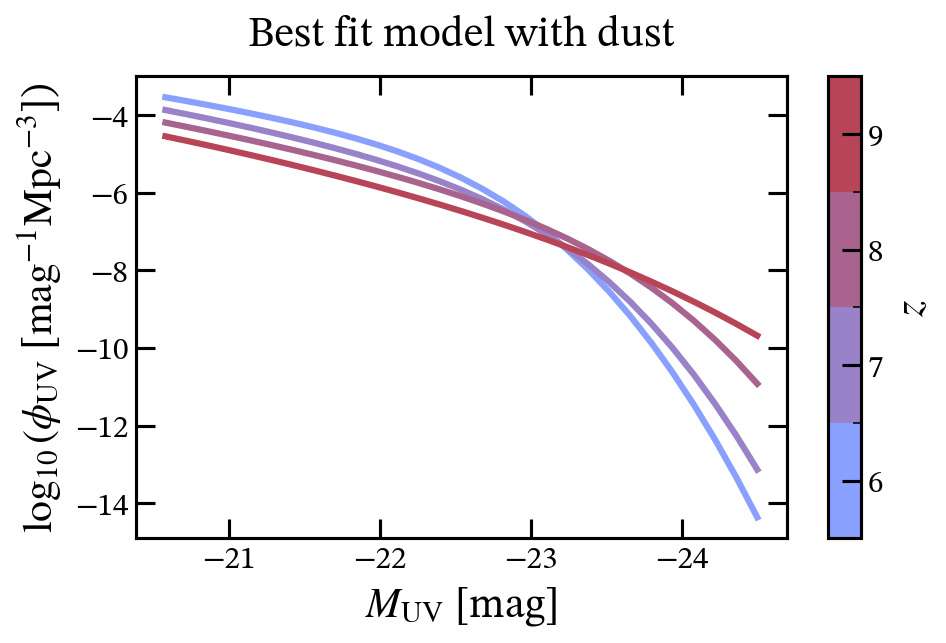

In [67]:
fig, ax = plt.subplots()
fig.set_size_inches(7, 4)
z_err = 0.5

cmap, sm, boundaries = eplots.create_custom_colorbar([eplots.periwinkle, eplots.red], zs)

for z in zs:
    frac = (z - min(zs)) / (max(zs) - min(zs))
    color = cmap(frac)
    ax.plot(MUVcenters, np.log10(my_UVLF.UVLF_wrapper(z, z_err, MUVcenters, MUVwidths, fit)), color = color, linestyle = '-', 
                                           zorder = 0, lw = 3)

ax.invert_xaxis()
cbar = fig.colorbar(sm, ax = ax, boundaries=boundaries, ticks=zs, aspect = 14)
cbar.set_label(r'$z$')

ylabel = r'$\log_{10}(\phi_{\rm{UV}}$ [$\rm{mag}^{-1} \rm{Mpc}^{-3}$])'
xlabel = r'$M_{\rm{UV}}$ [mag]'

ax.set_xlabel(xlabel)
ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
ax.set_ylabel(ylabel)
ax.set_title('Best fit model with dust')

In [54]:
fig.savefig('/Users/eb35267/Desktop/code/figures/bright_end_with_dust.png')

Text(0.5, 1.0, 'Best fit model, no dust')

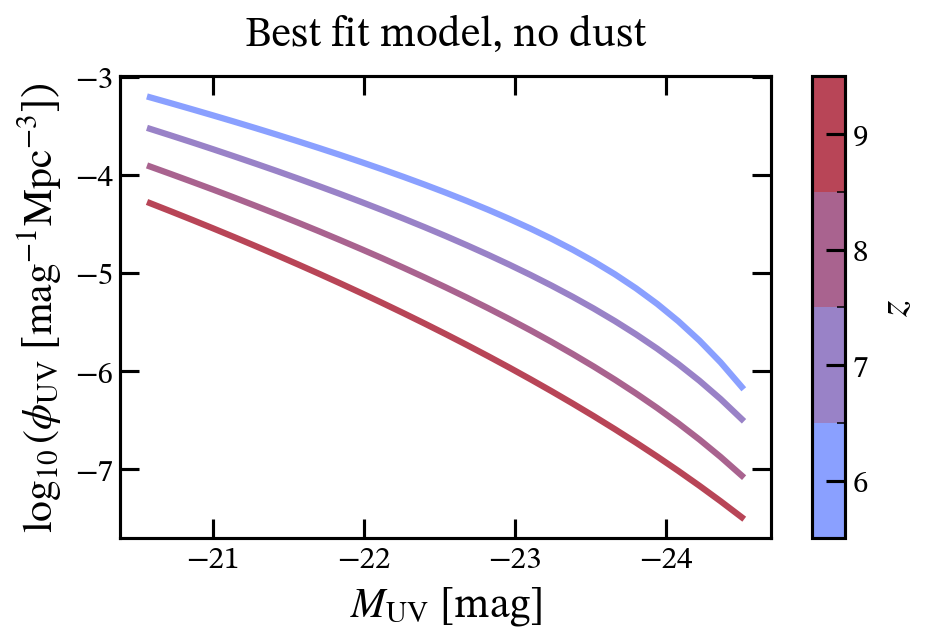

In [68]:
fig, ax = plt.subplots()
fig.set_size_inches(7, 4)
z_err = 0.5

cmap, sm, boundaries = eplots.create_custom_colorbar([eplots.periwinkle, eplots.red], zs)

for z in zs:
    frac = (z - min(zs)) / (max(zs) - min(zs))
    color = cmap(frac)
    ax.plot(MUVcenters, np.log10(my_UVLF.UVLF_wrapper(z, z_err, MUVcenters, MUVwidths, fit, dust_flag = False)), color = color, linestyle = '-', 
                                           zorder = 0, lw = 3)

ax.invert_xaxis()
cbar = fig.colorbar(sm, ax = ax, boundaries=boundaries, ticks=zs, aspect = 14)
cbar.set_label(r'$z$')

ylabel = r'$\log_{10}(\phi_{\rm{UV}}$ [$\rm{mag}^{-1} \rm{Mpc}^{-3}$])'
xlabel = r'$M_{\rm{UV}}$ [mag]'

ax.set_xlabel(xlabel)
ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
ax.set_ylabel(ylabel)
ax.set_title('Best fit model, no dust')

In [69]:
fig.savefig('/Users/eb35267/Desktop/code/figures/bright_end_no_dust.png')

In [72]:
4500/(360**2)

0.034722222222222224